# Degradation modelling

Created on 2026-04-20

This notebook recreates the Figs. 5 and 6 in the Manuscript [1].

[1] K. Jäger, J. Mandal, B. P. Rand, F. Meggers, and C. Becker. "How do sub-bandgap reflectors affect the performance of photovoltaic modules?" arXiv: 0000.0000 (2026)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pv_tandem.thermal import GetLocData, CalcEY
from scipy import constants

## Initialize energy yield class

In [2]:
# Initialize PV module dictionary
pv_dict = {
    # Geometrical parameters
    'module_height': 1.5,               # in m
    'module_width': 1.1,                # in m
    'module_length': 1.7,               # in m
    'module_spacing': 100,              # in m
    'module_tilt_deg': 34.5,            # optimal tilt for TMY 2024 data in Princeton
    'module_plane_azimuth_deg': 180,    # PV module is facing South
    'ground_steps': 101,                # steps in view factor model

    # Environmental parameter
    'albedo': 0.3,

    # Parameters for temperature models (Ross, Fuentes or SAPM, from pvlib)
    'fuentes_module_emissivity': 0.84,  # Default: 0.84, used in Fuentes model
    'noct': 45,                         # Used in Ross model     
    'sapm_module_mount': 0,             # Used in SAPM model
                                        # 0: glass/glass, open rack
                                        # 1: glass/glass, close roof
                                        # 2: glass/polymer, open rack
                                        # 3: glass/polymer, insulated back

    # Parameters for electrical one-diode model
    'j_sc_STC': 39,                     # Short circuit current density at STC
    'PCE': 24.76,                       # Power conversion efficiency of PV module at STC in %
    'tc_P': -0.40,                      # Temperature coefficient for power in %/K
    'tc_j_sc': 0.03,                    # Temperature coefficient for short-circuit current density in %/K
    'tc_V_oc': -0.4,                    # Temperature coefficient for open-circuit voltage in %/K
    'R_shunt': 3000,                    # Shunt resistance
    'R_series': 1.5,                    # Series resistance
    'n': 1,                             # Diode ideality factor
    'j_0': 1e-12,                       # Dark current density

    # Thermal coating parameter
    'loss': 0,                          # Loss of thermal coating

    # Filepath to csv file containing PV module reflectance
    'reflection_filepath': '../data_thermal/SEMSC_Subedi_ea_PERC_UVVisNIR_sim_2020_Fig5b.csv'
    }

# General configuration variables
config_dict = {'irrad_model': 'vf',     # Irradiation model. "vf" or "simple"
               'temp_model': 'SAPM',    # Temperature model "Ross", "Fuentes", or "SAPM"
               'spectral': True         # Set, whether NSRDB data is spectral or not
              }

In [3]:
# Load NSRDB data and populate the "loc_data" dictionary
nsrdb_data_filepath = '../data_thermal/princeton-2024-1223393-fixed_tilt_35_spectral.csv'
loc_data = GetLocData(nsrdb_data_filepath = nsrdb_data_filepath,
                      pv_reflection_filepath = pv_dict['reflection_filepath'],
                      spectral_boolean =config_dict['spectral']
                      ) 
# Initialize Class "CalcEY"
ey_test = CalcEY(loc_data = loc_data.data,
                 pv_dict = pv_dict,
                 config_dict = config_dict)

## Degradation modelling

In [4]:
def degradation_rate_simple(gamma,E_a,T_C):
    # Very simple model only assuming only Arrhenius function with activation energy E_a.
    T_K = T_C + 273.15 # convert from celsius to kelvin
    k_B = constants.physical_constants['Boltzmann constant in eV/K'][0] 
    rate = gamma * np.exp(-E_a/k_B/T_K)
    return rate

In [5]:
# Study effect for different E_a
E_a = np.linspace(0.4,0.8,5)

In [6]:
# Set gamma (such that degradation rate in Princeton for reference modules in open-rack installation is 1.0% per year.
ey_test.get_ey()
pv_dict['sapm_module_mount'] = 0
gamma = np.zeros(len(E_a))
for i, E_a_i in enumerate(E_a):
    rate = degradation_rate_simple(1,E_a_i,ey_test.res['module_temp_ref']).sum()
    gamma[i] = 1/rate
print(gamma)

[6.65535644e+02 2.92571836e+04 1.23655603e+06 5.04939413e+07
 2.00233593e+09]


In [7]:
# Calculate results
rates = np.ones([4,5])
ey_array = np.zeros([4])
for sapm_module_mount in [0,1]:
    pv_dict['sapm_module_mount'] = sapm_module_mount
    ey_test.get_ey() # TMY MODEL. NO SPECTRAL DATA
    for j, case in enumerate(['ref','sbr']):
        ey_array[j+2*sapm_module_mount] = ey_test.res['ey_'+case]
        for i, E_a_i in enumerate(E_a):
            rates[j+2*sapm_module_mount,i] = degradation_rate_simple(gamma[i],E_a_i,ey_test.res['module_temp_'+case]).sum()
lifetimes =  -np.log(0.8)/(rates/100)

In [8]:
print(ey_array)

[416.87521993 422.14000796 394.73603486 402.85074387]


In [9]:
print(rates)

[[1.         1.         1.         1.         1.        ]
 [0.93113634 0.90373109 0.87386726 0.84268197 0.81115683]
 [1.51446123 1.80185664 2.17717443 2.65242661 3.24140681]
 [1.32314798 1.48768382 1.69203439 1.93744973 2.22522768]]


In [10]:
# Calculate Arrays for cumulative energy yield for open-rack-mount
ey_cum_ref = np.zeros([5,31])
ey_cum_sbr = np.zeros([5,31])
ey_cum_ref[:,1] = ey_array[0]
ey_cum_sbr[:,1] = ey_array[1]
for i in range(1,30):
    for j in range(5):
        ey_cum_ref[j,i+1] = ey_cum_ref[j,i]+ey_cum_ref[j,1]*(1-rates[0,j]/100)**i#(i+1)
        ey_cum_sbr[j,i+1] = ey_cum_sbr[j,i]+ey_cum_sbr[j,1]*(1-rates[1,j]/100)**i#(i+1)

### Plot figures

C:\Users\kvz\AppData\Local\Temp\ipykernel_23440\4134928355.py:5: RuntimeWarning: divide by zero encountered in divide
  return -np.log(0.8)/(x/100)


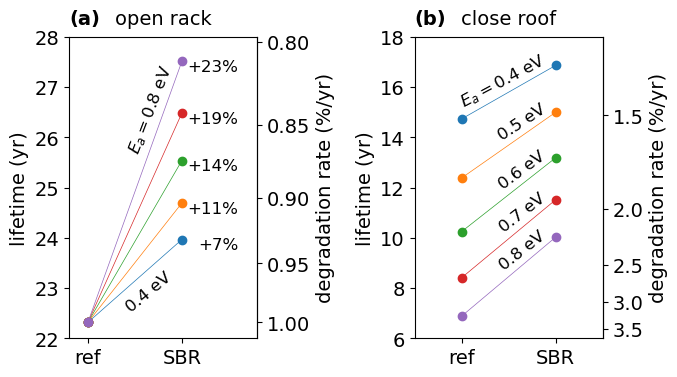

In [11]:
def lt(x):
    return -np.log(0.8)/(x/100)

def rt(x):
    return -np.log(0.8)/(x/100)

plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(1,2,figsize = (7,4))
ax[0].plot(lifetimes[0:2],marker = 'o', lw = .5, label=np.round(E_a,1))
ax[0].set_xticks([0,1],['ref','SBR'])
ax[0].set_xlim(-.2,1.8)
#ax[0].legend(frameon = 0)
#ax[0].set_title('open rack')
#plt.xlabel('wavelength (nm)')
ax[0].set_ylabel('lifetime (yr)')
ax[0].set_ylim(22,28)
secax = ax[0].secondary_yaxis('right',functions = (lt,rt))
secax.set_ylabel('degradation rate (%/yr)')
ax[0].text(-0.2,28.25,'(a)', weight = 'bold')
ax[0].text(0.8,28.25,'open rack',ha = 'center')

#plt.title('Irradiance of a blackbody with 5772 K covering 68.5 µsr solid angle, "The Sun"')
#plt.show()

#fig, ax = plt.subplots()
ax[1].plot(lifetimes[2:],marker = 'o', lw = .5, label=np.round(E_a,1))
ax[1].set_xticks([0,1],['ref','SBR'])
ax[1].set_xlim(-.5,1.5)
#ax[1].legend(title = "$E_a$ (eV)",frameon = 1)
#ax[1].set_title('closed roof')
#plt.xlabel('wavelength (nm)')
ax[1].set_ylabel('lifetime (yr)')
ax[1].set_ylim(6,18)
secax = ax[1].secondary_yaxis('right',functions = (lt,rt))
secax.set_ylabel('degradation rate (%/yr)')
ax[1].text(-.5,18.5,'(b)', weight = 'bold')
ax[1].text(0.5,18.5,'close roof',ha = 'center')
#plt.title('Irradiance of a blackbody with 5772 K covering 68.5 µsr solid angle, "The Sun"')

#ax[1].legend(bbox_to_anchor=(0.5, -0.1),fancybox=False, shadow=False, ncol=5)

for i in range(len(E_a)):
    diff = (lifetimes[1,i]-lifetimes[0,i])/lifetimes[0,1]
    avg_or = 0.1*lifetimes[0,i]+0.9*lifetimes[1,i]
    angle_or = np.degrees(np.atan2(lifetimes[1,i]-lifetimes[0,i],2))
    avg_cr = 0.1*lifetimes[2,i]+0.9*lifetimes[3,i]
    angle_cr = np.degrees(np.atan2(lifetimes[3,i]-lifetimes[2,i],4))
    ax[0].text(1.6,lifetimes[1,i]-.2,"{:+.0%}".format(diff),size = 12,ha = 'right')
    ax[1].text(0.9,avg_cr+.3,"{}{:.1} eV".format('$E_a=$' if i == 0 else '', E_a[i]),size = 12,rotation = angle_cr,rotation_mode = 'anchor',ha = 'right')
    if i in [0,4]:
        ax[0].text(0.9,avg_or-.6+.25*i,"{}{:.1} eV".format('$E_a=$' if i == 4 else '',E_a[i]),size = 12,rotation = angle_or,rotation_mode = 'anchor',ha = 'right')
        

fig.tight_layout()

plt.show()

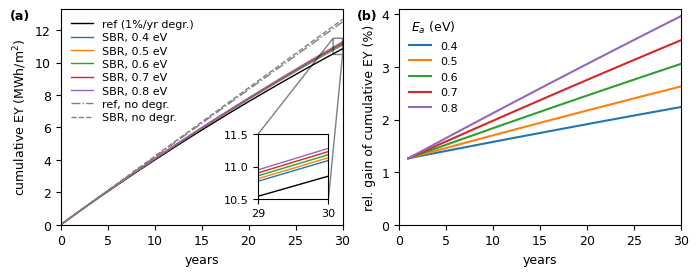

In [12]:
plt.rcParams['font.size'] = 9
fig, ax = plt.subplots(1,2,figsize = (8,2.8))

ax[0].plot(range(31),ey_cum_ref[3,:]/1e3,'k',lw=1,label = "ref (1%/yr degr.)")
for i,E_a_i in enumerate(E_a):
    ax[0].plot(range(31),ey_cum_sbr[i,:]/1e3,lw=1,label = "SBR, {:.1} eV".format(E_a_i))
    ax[1].plot(range(1,31),(ey_cum_sbr[i,1:]-ey_cum_ref[i,1:])/ey_cum_ref[i,1:]*100,label = "{:.1}".format(E_a_i))
ax[0].plot(range(31),ey_cum_ref[0,1]*(range(31))/1e3,'-.',color='gray',lw=1, label = "ref, no degr.")
ax[0].plot(range(31),ey_cum_sbr[0,1]*(range(31))/1e3,'--',color='gray',lw=1,label = "SBR, no degr.")

# Make inset
x1, x2, y1, y2 = 29, 30, 10.5, 11.5  # subregion of the original image
axins = ax[0].inset_axes(
    [0.7, 0.12, 0.25, 0.3],
    xlim=(x1, x2), ylim=(y1, y2), xticks = [29,30])
axins.tick_params(axis='both', labelsize=8)
axins.plot(range(31),ey_cum_ref[3,:]/1e3,lw = 1, color = 'k',label = "ref (1%/yr degr.)")
for i,E_a_i in enumerate(E_a):
    axins.plot(range(31),ey_cum_sbr[i,:]/1e3,lw = 1, label = "SBR, {:.1} eV".format(E_a_i))
ax[0].indicate_inset_zoom(axins, edgecolor="black")

ax[0].legend(frameon = 0,fontsize = 8,labelspacing = 0.3)
ax[0].set_xlabel('years')
ax[0].set_ylabel('cumulative EY (MWh/m$^2$)')
ax[0].set_ylim(bottom = 0)
ax[0].set_xlim(0,30)

ax[1].legend(frameon = 0,fontsize = 8,title = "$E_a$ (eV)")
ax[1].set_xlabel('years')
ax[1].set_ylabel('rel. gain of cumulative EY (%)')
ax[1].set_ylim(bottom = 0)
ax[1].set_xlim(0,30)

fig.align_ylabels()

ax[0].text(-.18,1,'(a)', transform=ax[0].transAxes, weight = 'bold',va = "top")
ax[1].text(-.15,1,'(b)', transform=ax[1].transAxes, weight = 'bold',va = "top")

plt.show()